# Hof_figures_comparison.ipynb

Multi-file version of `Hof_figures.ipynb`. Computes the SAME observables and
makes the SAME plots as that notebook, but for an arbitrary number of output
files at once, and lays every comparison plot out in a grid (one panel per
file) instead of one figure per notebook run.

**How this relates to `Hof_figures.ipynb`:** every formula/derivation below
is a direct port of that notebook's cells -- same variable names (now dict
keys), same comments (condensed), same numbers. If you change a formula in
one notebook, mirror the change in the other, they're not auto-synced.

**Pure-viscous runs (psi == 0):** ported from `Hof_figures.ipynb`'s
`psi == 0` handling. `compute_observables()` skips `integrate_wind_mass_loss_rate()`
(it requires psi > 0) and falls back to the unmasked, stellar-accretion-only
mass-loss rate over the full `t_snap` grid for `tau`. `is_pure_viscous`
(bool, per file) lets every plotting cell detect this instead of crashing on
the (then `None`) wind quantities; the wind-only panels (stellar accretion
vs disc-wind mass loss, wind-to-accretion ratio) show a "pure viscous run"
placeholder for those files instead of a plot.

**What's intentionally NOT reproduced here:** the per-snapshot mask
DIAGNOSTIC TABLE (`integrate_wind_mass_loss_rate()`'s finite/positive mask,
shown as a big `pandas` table in `Hof_figures.ipynb`). Use `Hof_figures.ipynb` directly on one file if you need to see which
snapshots got dropped and why.

**How to use:** fill in the `FILES` list and `GRID_SHAPE` a few cells down,
then Run All. Each file is loaded and processed independently (one failure
doesn't stop the rest -- see `compute_observables()`'s error handling), so a
missing file or a file this pipeline can't handle just shows up as a labelled
"FAILED" panel in every grid instead of crashing the notebook.

# Imports, Directories and constants

In [7]:
# Imports and formatting
# (verbatim from Hof_figures.ipynb's "Imports and formatting" cell)
import csv
import numpy as np
import h5py, json
import os, re, fnmatch
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import cycle
from itertools import product
from datetime import datetime
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from DiscEvolution.constants import *
from DiscEvolution.chemistry import *
from scipy.ndimage import uniform_filter1d
import matplotlib.ticker as ticker
from email import header

pd.set_option("display.max_colwidth", None)


In [8]:
# Directories
# (verbatim from Hof_figures.ipynb's "Directories" cell)
BASEDIR='/home/imontesd'
DATADIR=BASEDIR+'/output/DiscEvolution'
LITDATA=BASEDIR+'/output/DiscEvolution/litdata/'
CODEDIR=BASEDIR+'/DiscEvolution'
WORKINGDIR=BASEDIR+'/output/DiscEvolution/work/'
FIGDIR=BASEDIR+'/output/DiscEvolution/figures/'

# constants
m_Jupiter = 317.8 # earth masses

# Chemistry
#solar_H_fraction=0.73 # by mass
X_H_solar = 0.73
X_He_solar = 0.25
mu_H = 1.0
mu_He = 4.0
mu_HHe = 2.3     # mean molecular weight of H+He mixture
Y_H = 0.92       # hydrogen fraction in primordial mixture
OH_solar = 0.00784 # mass
CH_solar = 0.00324 # mass
SiH_solar = 3.2e-5*28. # mass
CH_solar_number=CH_solar/12.
OH_solar_number=OH_solar/16.
SiH_solar_number=SiH_solar/28.
OSi_solar_number=OH_solar_number/SiH_solar_number
Z_solar=0.02
SEC_PER_YEAR = 365.25 * 24.0 * 3600.0
ERAD_FIXED = 0.9
MU_GAS = 2.4

# Global execution switches
GENERATE_PKL = False # Set to true to regenerate pkl files from output.  Slow.


# Main method to read .h5 output files 

In [9]:
# Method to read HDF5output files
# (verbatim from Hof_figures.ipynb -- see that notebook for the full
#  cell-by-cell derivation history/comments on every dataset read here)
def load_data(fname,planets=False):
    """
    Load disc evolution output file (HDF5 only).

    Returns dict in JSON-equivalent format with consistent shapes.
    """

    with h5py.File(fname, "r") as f:
        data = {}
        # Extract psi value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # psi (= psi_DW) is the disc-wind mass-loss parameter. Units: dimensionless.
        psi = None
        m = re.search(r"psi([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            psi = float(m.group(1))
        # Extract erad value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # run_model_Hof.py::output_filename() writes the wind radiative-loss
        # efficiency into the filename as the token "erad" (the JSON config key
        # is "e_rad", with underscore) so it can be recovered here for the wind
        # mass-loss-rate calculation. Units: dimensionless fraction in [0, 1].
        # Same regex approach as psi above; stays None if the token is absent
        # (e.g. a file produced by the unmodified run_model_student.py).
        erad = None
        m = re.search(r"erad([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            erad = float(m.group(1))
        # Scalars
        for key in ["t", "disk_Mdot_star", "disk_Mass", "Tc", "Sigc"]:
            if key in f:
                data[key] = f[key][()].tolist()
        data["alpha_SS"] = f.attrs.get("alpha_SS", None)
        data["psi"] = psi      # disc-wind mass-loss parameter psi_DW [dimensionless], from filename
        data["erad"] = erad    # wind radiative-loss efficiency e_rad [dimensionless, 0-1], from filename
        # Helper for ragged vs extendable vs single-dump
        def read_array(obj):
            if isinstance(obj, h5py.Dataset):       # dataset directly
                arr = obj[()]
                if np.ndim(arr) == 0:   # scalar
                    return [float(arr)]
                return np.array(arr).tolist()
            elif isinstance(obj, h5py.Group):       # ragged group
                vals = [obj[k][()] for k in sorted(obj.keys(), key=int)]
                return [float(v) for v in vals]
            else:
                raise TypeError(f"Unexpected type {type(obj)}")

        # ---------------- Per-planet arrays ----------------
        if (planets):
            data["Mcs"], data["Mes"], data["Rp"], data["disk_Mdot_p"] = [], [], [], []

            if isinstance(f.get("Mcs"), h5py.Dataset):
                # Single dataset case
                arr = np.array(f["Mcs"])
                data["Mcs"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mcs"].keys(), key=int):
                    data["Mcs"].append(read_array(f["Mcs"][ip]))

            if isinstance(f.get("Mes"), h5py.Dataset):
                arr = np.array(f["Mes"])
                data["Mes"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mes"].keys(), key=int):
                    data["Mes"].append(read_array(f["Mes"][ip]))

            if isinstance(f.get("Rp"), h5py.Dataset):
                arr = np.array(f["Rp"])
                data["Rp"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Rp"].keys(), key=int):
                    data["Rp"].append(read_array(f["Rp"][ip]))

            if isinstance(f.get("disk_Mdot_p"), h5py.Dataset):
                arr = np.array(f["disk_Mdot_p"])
                data["disk_Mdot_p"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["disk_Mdot_p"].keys(), key=int):
                    data["disk_Mdot_p"].append(read_array(f["disk_Mdot_p"][ip]))
        # alpha_SS handling
        if "alpha_SS" in f.attrs:             # new streaming files
            data["alpha_SS"] = float(f.attrs["alpha_SS"])
        elif "alpha_SS" in f:                  # old single-dump files
            data["alpha_SS"] = f["alpha_SS"][()]
        else:
            data["alpha_SS"] = None
        # File attributes
        data["complete"] = f.attrs.get("complete", False)

        # ---------------- Chemistry ----------------
        if (planets):
            data["X_cores"], data["X_envs"] = [], []
            if "X_cores" in f:
                if isinstance(f["X_cores"], h5py.Dataset):
                    # Single dataset case — probably shaped (nplanets, nspecies, nsteps?)
                    arr_core = np.array(f["X_cores"])
                    arr_env  = np.array(f["X_envs"])
                    nplanets = arr_core.shape[0]
                    for ip in range(nplanets):
                        core_species = [arr_core[ip, js, :].tolist() for js in range(arr_core.shape[1])]
                        env_species  = [arr_env[ip, js, :].tolist()  for js in range(arr_env.shape[1])]
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)
                else:
                    # Group → streaming or ragged format
                    for ip in sorted(f["X_cores"].keys(), key=int):
                        core_species = []
                        env_species  = []
                        for js in sorted(f["X_cores"][ip].keys(), key=int):
                            core_species.append(read_array(f["X_cores"][ip][js]))
                        for js in sorted(f["X_envs"][ip].keys(), key=int):
                            env_species.append(read_array(f["X_envs"][ip][js]))
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)


        # ---------------- Disk profiles ----------------
        if "R" in f:
            data["R"] = f["R"][:].tolist()
        else:
            nR = f["Sigma_G"].shape[1]
            data["R"] = list(range(nR))  # placeholder if R not saved

        for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "T", "Sigma_pebble_size", "Vdrift"]:
            if key in f:
                data[key] = f[key][:].tolist()
        if "Sigma_planetesimals" in f:
            data["Sigma_planetesimals"] = f["Sigma_planetesimals"][:].tolist()
        # Dense-cadence Sigma_G, only present in run_model_Hof_dense.py output
        # (filename contains "_dense_"). Sigma_G_dense has one row per write
        # inside the [DENSE_T_MIN_MYR, DENSE_T_MAX_MYR] window that run used
        # (see run_model_Hof_dense.py), NOT one row per time_snap entry -- so
        # it does NOT align with Sigma_G/time_snap, and generally has far more
        # rows. Sigma_G_dense_t [years] is its own matching per-row timestamp;
        # use that, not time_snap, to plot/index into Sigma_G_dense.
        if "Sigma_G_dense" in f:
            data["Sigma_G_dense"] = f["Sigma_G_dense"][:].tolist()
        if "Sigma_G_dense_t" in f:
            data["Sigma_G_dense_t"] = f["Sigma_G_dense_t"][:].tolist()
        if "time_snap" in f:
            data["time_snap"] = f["time_snap"][:].tolist()
        # Extract ice line locations (water ice line)
        if "disk_ice_lines" in f:
            data["disk_ice_lines"] = f["disk_ice_lines"][:].tolist()
        chemdata=True
        try:
            for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                        "disk_atom_ice_abund", "disk_mol_ice_abund",
                        "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
                if key in f:
                    data[key] = np.array(f[key][:], dtype=float).tolist()
        except:
            chemdata=False


    # ---------------- Normalize shapes ----------------
    data["R"] = np.array(data["R"], dtype=float).squeeze()  # always (nR,)

    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)          # (nsnapshots, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]           # squeeze accidental middle dim
            data[key] = arr

    # Ensure R is always 1D
    data["R"] = np.array(data["R"], dtype=float)

    if data["R"].ndim == 2:
        # Old HDF5 case: R repeated for each snapshot
        # Keep just one copy (they should all be identical)
        data["R"] = data["R"][0, :]

    data["R"] = data["R"].squeeze()


    # Normalize disk profile arrays to (nsnap, nR)
    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.array(data[key], dtype=float)
            arr = np.atleast_2d(arr)  # (nsnap, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]
            data[key] = arr
    if "time_snap" in data:
        data["time_snap"] = np.array(data["time_snap"], dtype=float)
    # Sigma_G_dense / Sigma_G_dense_t: (n_dense, nR) / (n_dense,), NOT tied to
    # time_snap's length -- see comment where these are read, above.
    if "Sigma_G_dense" in data:
        data["Sigma_G_dense"] = np.atleast_2d(np.array(data["Sigma_G_dense"], dtype=float))   # [g/cm^2]
    if "Sigma_G_dense_t" in data:
        data["Sigma_G_dense_t"] = np.array(data["Sigma_G_dense_t"], dtype=float)              # [years]
    # Normalize disk_ice_lines to (nsnap, nR)
    if "disk_ice_lines" in data:
        arr = np.array(data["disk_ice_lines"], dtype=float)
        arr = np.atleast_2d(arr)  # (nsnap, nR)
        if arr.ndim == 3 and arr.shape[1] == 1:
            arr = arr[:, 0, :]
        data["disk_ice_lines"] = arr
    if (chemdata):
        for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                    "disk_atom_ice_abund", "disk_mol_ice_abund",
                    "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
            if key in data:
                arr = np.array(data[key], dtype=float)
                # Expected shape: (nsnap, Nspecies, nR)
                if arr.ndim == 2:  # in case nsnap=1
                    arr = arr[np.newaxis, ...]
                data[key] = arr

    return data


## Other helper functions

In [10]:
# === OTHER HELPER FUNCTIONS ===
# First part (through integrate_wind_mass_loss_rate) is verbatim from
# Hof_figures.ipynb's "OTHER HELPER FUNCTIONS" cell. R50() and
# _R_at_N_gas_threshold() are HOISTED here from single-file cells in
# Hof_figures.ipynb (there they're defined inline, right where they're used,
# since that notebook only ever processes one file per run) so
# compute_observables() below can call them for every file in the loop.

def extract_disk_mass_from_filename(filename):
    """
    Extract initial disk mass from filename pattern (e.g., "_M1.5e-01" -> 0.15 solar masses).
    """
    if pd.isna(filename):
        return np.nan

    # Pattern like "_M5.0e-02" for 0.05 solar masses
    m_match = re.search(r'_M([0-9.eE+-]+)', filename)
    if m_match:
        return float(m_match.group(1))  # Solar masses
    else:
        return np.nan

def extract_e_rad_from_filename(filename):
    return None

def integrate_surface_density_mass(sim_data, sigma_key):
    """
    Integrate total mass from surface density profile:
        M = 2*pi * integral[ Sigma(R) * R dR ]
    Sigma in g/cm^2, R in AU.
    Returns mass in grams as a function of time.
    """
    if sigma_key not in sim_data:
        raise KeyError(f"{sigma_key} not found in sim_data")

    # Radius key fallback
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float)
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float)
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc']).")

    Sigma = np.asarray(sim_data[sigma_key], dtype=float)
    R_cm = R_au * AU

    if Sigma.ndim == 1:
        # Single snapshot
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm, R_cm)
        return np.array([M_g], dtype=float)

    if Sigma.ndim != 2:
        raise ValueError(f"Unexpected shape for {sigma_key}: {Sigma.shape}")

    nr = R_cm.size
    if Sigma.shape[-1] == nr:
        # Shape (nt, nr)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[None, :], R_cm, axis=1)
    elif Sigma.shape[0] == nr:
        # Shape (nr, nt)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[:, None], R_cm, axis=0)
    else:
        raise ValueError(f"Cannot align {sigma_key} shape {Sigma.shape} with R shape {R_cm.shape}")

    return np.asarray(M_g, dtype=float)

def _as_snapshot_matrix(arr, nr, name):
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        if a.size != nr:
            raise ValueError(f"{name} has length {a.size}, expected {nr}")
        a = a[None, :]

    elif a.ndim == 2:
        if a.shape[-1] == nr:
            pass
        elif a.shape[0] == nr:
            a = a.T
        else:
            raise ValueError(f"Cannot align {name} shape {a.shape} with nr={nr}")

    else:
        raise ValueError(f"Unexpected {name} ndim={a.ndim}")

    return a

def _interpolate_mdot_star_to_snapshots(sim_data, t_snap):
    t_mdot = np.asarray(sim_data.get("t", []), dtype=float)
    mdot = np.asarray(sim_data.get("disk_Mdot_star", []), dtype=float)
    if t_mdot.size == 0 or mdot.size == 0:
        raise KeyError("sim_data must include 't' and 'disk_Mdot_star'")

    n = min(t_mdot.size, mdot.size)
    t_mdot = t_mdot[:n]
    mdot = mdot[:n]

    # If t is in years while snapshots are in Myr, convert t for interpolation.
    if np.nanmax(t_mdot) > 1.0e3 and np.nanmax(t_snap) < 1.0e2:
        t_mdot_use = t_mdot / 1.0e6
    else:
        t_mdot_use = t_mdot

    return np.interp(t_snap, t_mdot_use, mdot, left=np.nan, right=np.nan)

def integrate_wind_mass_loss_rate(sim_data, erad=ERAD_FIXED, mu=MU_GAS):
    """
    Integrate wind mass-loss rate over radius at each snapshot and return:
    x = stellar accretion rate at snapshot times [Msun/yr]
    y = integrated wind loss rate [Msun/yr]
    """
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float).squeeze()
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float).squeeze()
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc'])")
    if "Sigma_G" not in sim_data or "T" not in sim_data:
        raise KeyError("sim_data must include 'Sigma_G' and 'T'")

    psi = float(sim_data.get("psi", np.nan))
    alpha_ss = float(sim_data.get("alpha_SS", np.nan))
    if not np.isfinite(psi) or not np.isfinite(alpha_ss) or psi <= 0.0:
        raise ValueError(f"Invalid psi/alpha_SS: psi={psi}, alpha_SS={alpha_ss}")

    # alpha_DW / alpha_SS = psi
    alpha_dw = psi * alpha_ss

    nr = R_au.size
    Sigma = _as_snapshot_matrix(sim_data["Sigma_G"], nr, "Sigma_G")
    Temp = _as_snapshot_matrix(sim_data["T"], nr, "T")

    t_snap = np.asarray(sim_data.get("time_snap", []), dtype=float)
    if t_snap.size == 0:
        raise KeyError("sim_data must include 'time_snap' to align with disk_Mdot_star")

    ns = min(t_snap.size, Sigma.shape[0], Temp.shape[0])
    t_snap = t_snap[:ns]
    Sigma = Sigma[:ns, :]
    Temp = Temp[:ns, :]

    R_cm = R_au * AU
    Omega_K = Omega0 * np.power(R_au, -1.5)  # Solar-mass star
    cs2 = (GasConst / mu) * Temp

    # dotSigma_w = (3/2)*(cs^2/(Omega*R^2))*(1-erad)*alpha_DW*Sigma*(3/psi + 1)
    prefac = 1.5 * (1.0 - erad) * alpha_dw * (3.0 / psi + 1.0)
    sigma_dot_w = prefac * (cs2 / (Omega_K[None, :] * R_cm[None, :]**2)) * Sigma

    # dotM_w = 2*pi*integral(dotSigma_w * R dR)
    mdot_w_g_per_s = 2.0 * np.pi * np.trapezoid(sigma_dot_w * R_cm[None, :], R_cm, axis=1)
    mdot_w_msun_per_yr = mdot_w_g_per_s * SEC_PER_YEAR / Msun

    mdot_star_snap = _interpolate_mdot_star_to_snapshots(sim_data, t_snap)

    ok = np.isfinite(mdot_star_snap) & np.isfinite(mdot_w_msun_per_yr)
    ok &= (mdot_star_snap > 0.0) & (mdot_w_msun_per_yr > 0.0)

    return mdot_star_snap[ok], mdot_w_msun_per_yr[ok], t_snap[:ns][ok]

def R50(R, Sigma_G_row):
    """Mass-weighted half-radius (median-mass radius) of one Sigma_G(R) profile [AU]."""
    dM = 2*np.pi*R*Sigma_G_row
    M_cum = np.concatenate([[0], np.cumsum(0.5*(dM[1:]+dM[:-1])*np.diff(R))])
    return np.interp(0.5*M_cum[-1], M_cum, R)

def _R_at_N_gas_threshold(R_au, Sigma_G_row, N_gas_thresh, mu=MU_GAS):
    """
    Outermost grid radius [AU] where the gas column NUMBER density
    N_gas(R) = Sigma_G/(mu*m_H) [cm^-2] is still >= N_gas_thresh -- mirrors
    the density-threshold approach AccretionDisc.Rout() uses in disc.py.
    Returns NaN if the threshold is never reached.
    """
    N_gas_R = Sigma_G_row / (mu * m_H)        # [cm^-2]
    above = N_gas_R >= N_gas_thresh
    return R_au[above][-1] if np.any(above) else np.nan

print("✅ HELPER FUNCTIONS defined successfully!")


✅ HELPER FUNCTIONS defined successfully!


## Files to compare + grid layout

`FILES`: one entry per output file. `label` becomes that file's panel title
in every comparison grid below -- keep it short (a full filename is long and
mostly redundant with its neighbours in a sweep). If you omit `label`, the
filename (without directory or `.h5`) is used instead.

`GRID_SHAPE`: `(nrows, ncols)`, used by every comparison plot below. **You
are responsible for `nrows*ncols` being consistent with `len(FILES)`** 


In [11]:
# Add one entry per grid slot -- in ROW-MAJOR order (fills row 0 left-to-right,
# then row 1, ...), matching GRID_SHAPE below. 

# Use None (not a dict) for a grid slot whose sweep run never produced an
# output file (crashed, aborted, still queued, ...) 

FILES = [
    # ---- row 0: M = 0.01 ----
    {"filename": "hof_discwind_sweep3.00_psi0.0_erad1.0_Mdot1.0e-09_M1.0e-02_Rd5.0e+01.h5",
     "label": "M=0.01, Mdot=1e-9"},
    {"filename": "hof_discwind_sweep3.01_psi0.0_erad1.0_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5",
     "label": "M=0.01, Mdot=1e-8"},
    {"filename": "hof_discwind_sweep3.02_psi0.0_erad1.0_Mdot1.0e-07_M1.0e-02_Rd5.0e+01.h5",
     "label": "M=0.01, Mdot=1e-7"},
    # ---- row 1: M = 0.1 ----
    {"filename": "hof_discwind_sweep3.10_psi0.0_erad1.0_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5",
     "label": "M=0.1, Mdot=1e-9"},
    {"filename": "hof_discwind_sweep3.11_psi0.0_erad1.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5",
     "label": "M=0.1, Mdot=1e-8"},
    {"filename": "hof_discwind_sweep3.12_psi0.0_erad1.0_Mdot1.0e-07_M1.0e-01_Rd5.0e+01.h5",
     "label": "M=0.1, Mdot=1e-7"},
    ]

GRID_SHAPE = (2, 3)   # (nrows, ncols) -- must hold len(FILES) SLOTS (a None counts as a slot)

n_panels = GRID_SHAPE[0] * GRID_SHAPE[1]
if n_panels < len(FILES):
    print(f"WARNING: GRID_SHAPE {GRID_SHAPE} has only {n_panels} panel(s) for {len(FILES)} slots "
          f"-- the last {len(FILES) - n_panels} slot(s) will be silently dropped from every grid below.")
elif n_panels > len(FILES):
    print(f"Note: GRID_SHAPE {GRID_SHAPE} has {n_panels} panel(s) for {len(FILES)} slots "
          f"-- {n_panels - len(FILES)} panel(s) will be left blank.")
else:
    print(f"GRID_SHAPE {GRID_SHAPE} matches {len(FILES)} slot(s) -- OK")

n_none = sum(1 for entry in FILES if entry is None)
if n_none:
    print(f"{n_none} slot(s) explicitly left blank (None) for sweep points with no output file")


GRID_SHAPE (2, 3) matches 6 slot(s) -- OK


## Analysis parameters (shared across all files)

Every tunable constant used by `compute_observables()` below, collected in
one place -- same values Hof_figures.ipynb currently uses. Change here once
rather than hunting through the function body.

In [12]:
DELTA_C = 0.2          # [dimensionless] carbon-depletion factor for the R_CO,90 threshold
                        # (Tabone et al. 2025 extension to Trapman et al. 2023 Eq. 3 -- see
                        # compute_observables() below, "R_CO,90" section)

STEPS_PER_WRITE = 5     # simulation-step cadence disk_Mdot_star (Mdot_t) is written at
                        # (see run_model_Hof.py _integrate(): `if (n % 5 == 0): ...`)
N_STEPS_BLOCK_AVG = 100 # simulation steps to average Mdot_t over, for the block-average plot
                        # (100 / STEPS_PER_WRITE = 20 consecutive Mdot_t entries per output point)

R_ZOOM_MIN, R_ZOOM_MAX = 0.1, 1.0   # [AU] inner-disc zoom window for the dense Sigma_G heatmap
                                     # (R_ZOOM_MIN just above grid rmin = 0.1 AU)


## Compute observables for every file

In [13]:
def compute_observables(filename, label=None, delta_C=DELTA_C):
    """
    Run the full single-file analysis pipeline from Hof_figures.ipynb on ONE
    output file and return every derived quantity in one dict, so results can
    be stored per-file (in the `results` list built in the next cell) and
    reused by every grid-plotting cell further down.

    This is a straight port of the "t/t_Myr/t_snap/Mdisc_t/Mdot_t" through
    "Sigma_total_tsnap/Mdot_total_tsnap_mask/tau" cells in Hof_figures.ipynb --
    same formulas, same variable names (now dict keys), same numbers -- so
    results here should match that notebook run on the same file. See that
    notebook for the full derivation comments on each quantity; only a short
    reminder is kept here.

    Pure-viscous runs (psi == 0, i.e. no disc-wind term -- ported from
    Hof_figures.ipynb's `if data["psi"] != 0 / else:` branches in its
    "erad / t_snap_mask / Mdot_tsnap" and "tau" cells): integrate_wind_mass_loss_rate()
    requires psi > 0 (it raises ValueError otherwise -- see that function's
    guard clause above), so it is skipped entirely for these runs.
    t_snap_mask / Mdot_tsnap_mask / Mdot_wind_tsnap_mask are then left as
    None, and tau falls back to the UNMASKED Mdot_tsnap (stellar accretion
    only, there is no wind term to add) aligned to the FULL t_snap grid
    instead of t_snap_mask. `is_pure_viscous` (bool) and `tau_t_snap` (the
    t_snap array actually paired 1:1 with `tau`/`tau_Myr` -- t_snap_mask
    normally, t_snap for a pure-viscous run) are exposed below so every
    plotting cell can branch on this case instead of crashing on the None
    wind quantities.

    Returns
    -------
    dict, always containing:
        filename, label, error (None on success, else a short message)
    On success (error is None), ALSO containing:
        data                    raw dict from load_data() (profiles etc.)
        t [yr] (list), t_Myr [Myr], t_snap [Myr] (dense-t-grid & snapshot-grid times)
        Mdisc_t [g]              total (gas+dust) disc mass, dense-t-grid
        Mdot_t [Msun/yr]         accretion rate onto star, dense-t-grid
        Mgas_tsnap [Msun]        gas mass integrated from Sigma_G, per t_snap
        erad [dimensionless]     wind radiative-loss efficiency, from filename
        is_pure_viscous          True if this run has psi == 0 (no disc wind)
        Mdot_tsnap [Msun/yr]     Mdot_t interpolated onto t_snap (UNMASKED)
        t_snap_mask [Myr]        snapshots kept by integrate_wind_mass_loss_rate()'s
                                  mask -- None if is_pure_viscous
        Mdot_tsnap_mask, Mdot_wind_tsnap_mask [Msun/yr]  (paired, aligned to
                                  t_snap_mask) -- None if is_pure_viscous
        R50_tsnap [AU]           mass-weighted half-radius, per t_snap
        Mdisc_g_tsnap [g], N_gas_R_CO_90 [cm^-2], R_CO90_tsnap [AU] RCO90 evolution over t_snap and other useful variables calculated in the process
        Sigma_total_tsnap [g/cm^2]   gas+dust+pebbles(+planetesimals) surface density
        Mdisc_tsnap [Msun]       total disc mass integrated from Sigma_total_tsnap
        Mdot_total_tsnap_mask [Msun/yr]   Mdot_tsnap_mask + Mdot_wind_tsnap_mask,
                                  or just Mdot_tsnap (no wind term) if is_pure_viscous
        tau [yr], tau_Myr [Myr]  disc mass / total mass-loss rate, aligned to
                                  tau_t_snap (== t_snap_mask, or t_snap if is_pure_viscous)
        tau_t_snap [Myr]         the t_snap array paired 1:1 with tau/tau_Myr (see above)

    On failure (error is not None), ONLY filename/label/error are set --
    everything else is deliberately absent, so every plotting cell below
    checks `if res["error"]:` before touching any other key.
    """
    res = {"filename": filename, "label": label or os.path.splitext(filename)[0], "error": None}
    try:
        data = load_data(os.path.join(DATADIR, filename))
        res["data"] = data

        # ---- t / t_Myr / t_snap / Mdisc_t / Mdot_t ----
        t = data["t"]                                    # [yr]
        t_Myr = np.asarray(t, dtype=float) / 1e6
        t_snap = data["time_snap"]                        # [Myr]
        Mdisc_t = data["disk_Mass"]                        # total mass, gas+dust [g]
        Mdot_t = data["disk_Mdot_star"]                    # [Msun/yr]

        # ---- Mgas_tsnap: gas mass integrated from Sigma_G, per t_snap [Msun] ----
        # (does not exactly replicate AccretionDisc.Mtot()'s edge-area integration --
        #  fine for trends, not for exact-consistency checks; see Hof_figures.ipynb)
        R = np.asarray(data["R"])                          # [AU]
        Mgas_tsnap = np.array([
            np.trapezoid(sigma_g_row * 2*np.pi*R, R) * AU**2 / Msun
            for sigma_g_row in data["Sigma_G"]
        ])

        # ---- erad / Mdot_tsnap / masked wind quantities ----
        erad = data["erad"]                                # use THIS run's own erad, not ERAD_FIXED
        Mdot_tsnap = _interpolate_mdot_star_to_snapshots(data, t_snap)   # [Msun/yr], unmasked

        # Pure-viscous run (psi == 0): no disc-wind term exists, so there is
        # nothing for integrate_wind_mass_loss_rate() to integrate -- it
        # requires psi > 0 and raises ValueError otherwise (see that
        # function's guard clause above). Ported from Hof_figures.ipynb's
        # `if data["psi"] != 0: ... else: ...` branch in its
        # "erad / t_snap_mask / Mdot_tsnap" cell.
        is_pure_viscous = (data["psi"] == 0)
        if not is_pure_viscous:
            Mdot_tsnap_mask, Mdot_wind_tsnap_mask, t_snap_mask = integrate_wind_mass_loss_rate(data, erad)
        else:
            Mdot_tsnap_mask, Mdot_wind_tsnap_mask, t_snap_mask = None, None, None

        # ---- R50_tsnap: mass-weighted half-radius, per t_snap [AU] ----
        R50_tsnap = np.array([R50(np.asarray(data["R"]), row) for row in data["Sigma_G"]])

        # ---- R_CO,90: Trapman et al. 2023 Eq. 3, extended by delta_C (Tabone et al. 2025) ----
        Mdisc_g_tsnap = np.interp(t_snap, np.asarray(t, dtype=float) / 1e6,
                                   np.asarray(Mdisc_t, dtype=float),
                                   left=np.nan, right=np.nan)                # [g], NaN at ends is expected
        N_gas_R_CO_90 = 3.7e21 * delta_C ** -1 * (Mdisc_g_tsnap / Msun) ** 0.34   # [cm^-2]
        R_CO90_tsnap = np.array([
            _R_at_N_gas_threshold(np.asarray(data["R"]), sigma_row, N_thresh)
            for sigma_row, N_thresh in zip(data["Sigma_G"], N_gas_R_CO_90)
        ])                                                   # [AU]

        # ---- Sigma_total_tsnap / Mdisc_tsnap / tau ----
        R_au = np.asarray(data["R"], dtype=float)
        Sigma_total_tsnap = (np.asarray(data["Sigma_G"], dtype=float)           # gas          [g/cm^2]
                              + np.asarray(data["Sigma_dust"], dtype=float)     # small grains [g/cm^2]
                              + np.asarray(data["Sigma_pebbles"], dtype=float)) # pebbles      [g/cm^2]
        if "Sigma_planetesimals" in data:
            Sigma_total_tsnap = Sigma_total_tsnap + np.asarray(data["Sigma_planetesimals"], dtype=float)

        Mdisc_tsnap = np.array([
            np.trapezoid(sigma_row * 2*np.pi*R_au, R_au) * AU**2      # [g]
            for sigma_row in Sigma_total_tsnap
        ]) / Msun                                                     # [Msun]

        if not is_pure_viscous:
            keep = np.isin(t_snap, t_snap_mask)          # True at the snapshots the mask kept
            Mdisc_tsnap_kept = Mdisc_tsnap[keep]          # [Msun], aligned to t_snap_mask
            if not (len(Mdisc_tsnap_kept) == len(Mdot_tsnap_mask) == len(Mdot_wind_tsnap_mask)):
                raise ValueError("Mdisc_tsnap and the masked Mdot series are not aligned -- check t_snap_mask")

            Mdot_total_tsnap_mask = Mdot_tsnap_mask + Mdot_wind_tsnap_mask   # [Msun/yr]
            tau_t_snap = t_snap_mask                                        # [Myr]
        else:
            # No wind mask to align to -- use the full (unmasked) disc mass
            # and the stellar-accretion-only loss rate over the FULL t_snap
            # grid. Ported from Hof_figures.ipynb's `if _psi != 0: ... else:
            # ...` branch in its "tau" cell.
            Mdisc_tsnap_kept = Mdisc_tsnap                                   # [Msun], aligned to t_snap
            Mdot_total_tsnap_mask = Mdot_tsnap                               # [Msun/yr], no wind term to add
            tau_t_snap = t_snap                                             # [Myr]

        tau = Mdisc_tsnap_kept / Mdot_total_tsnap_mask                    # [yr]
        tau_Myr = tau / 1e6                                               # [Myr]

        res.update(dict(
            t=t, t_Myr=t_Myr, t_snap=t_snap, Mdisc_t=Mdisc_t, Mdot_t=Mdot_t,
            Mgas_tsnap=Mgas_tsnap,
            erad=erad, is_pure_viscous=is_pure_viscous,
            Mdot_tsnap=Mdot_tsnap, t_snap_mask=t_snap_mask,
            Mdot_tsnap_mask=Mdot_tsnap_mask, Mdot_wind_tsnap_mask=Mdot_wind_tsnap_mask,
            R50_tsnap=R50_tsnap,
            Mdisc_g_tsnap=Mdisc_g_tsnap, N_gas_R_CO_90=N_gas_R_CO_90, R_CO90_tsnap=R_CO90_tsnap,
            Sigma_total_tsnap=Sigma_total_tsnap, Mdisc_tsnap=Mdisc_tsnap,
            Mdot_total_tsnap_mask=Mdot_total_tsnap_mask, tau=tau, tau_Myr=tau_Myr,
            tau_t_snap=tau_t_snap,
        ))
    except Exception as e:
        # One bad file (missing, wrong shape, invalid psi/alpha_SS, ...) must not
        # take down the whole comparison -- record it and move on. Every plotting
        # cell below shows this as a labelled "FAILED" panel instead of crashing.
        res["error"] = f"{type(e).__name__}: {e}"
    return res


In [14]:
# Run the pipeline on every file in FILES, store results, report per-file status.
#
# A None entry in FILES (a sweep point with no output file -- see the cell
# above) is kept as None here too rather than dropped. That is what lets
# plot_grid() below place a blank panel in exactly that grid slot instead of
# shifting every later file's panel over by one.
results = [
    compute_observables(entry["filename"], entry.get("label")) if entry is not None else None
    for entry in FILES
]

for entry, res in zip(FILES, results):
    if res is None:
        print(f"{'SKIPPED (blank slot)':40s} (no file for this grid position)")
        continue
    status = f"FAILED  ({res['error']})" if res["error"] else "OK"
    print(f"{status:40s} {res['label']}  <- {res['filename']}")


OK                                       M=0.01, Mdot=1e-9  <- hof_discwind_sweep3.00_psi0.0_erad1.0_Mdot1.0e-09_M1.0e-02_Rd5.0e+01.h5
OK                                       M=0.01, Mdot=1e-8  <- hof_discwind_sweep3.01_psi0.0_erad1.0_Mdot1.0e-08_M1.0e-02_Rd5.0e+01.h5
OK                                       M=0.01, Mdot=1e-7  <- hof_discwind_sweep3.02_psi0.0_erad1.0_Mdot1.0e-07_M1.0e-02_Rd5.0e+01.h5
OK                                       M=0.1, Mdot=1e-9  <- hof_discwind_sweep3.10_psi0.0_erad1.0_Mdot1.0e-09_M1.0e-01_Rd5.0e+01.h5
OK                                       M=0.1, Mdot=1e-8  <- hof_discwind_sweep3.11_psi0.0_erad1.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01.h5
OK                                       M=0.1, Mdot=1e-7  <- hof_discwind_sweep3.12_psi0.0_erad1.0_Mdot1.0e-07_M1.0e-01_Rd5.0e+01.h5


## Grid-plotting helper

In [15]:
def plot_grid(draw_fn, suptitle=None, figsize_per_panel=(4.3, 3.4)):
    """
    Create a GRID_SHAPE grid of subplots -- one panel per entry in `results`,
    in order -- and call draw_fn(ax, res) to render one file's version of a
    single plot type into its own panel.

    Each results[i] falls into one of three cases:
      - a successful dict (error is None)  -> draw_fn(ax, res) renders it normally.
      - a failed dict (error is set)        -> a red "FAILED: <reason>" panel,
        WITHOUT calling draw_fn -- e.g. the file was missing, or psi/alpha_SS
        was invalid.
      - None -- a grid slot you deliberately left blank in FILES (e.g. a sweep
        point whose run never produced an output file) -> the panel is simply
        turned off, same as an unused trailing slot. This is different from
        "FAILED": None means "nothing was ever attempted here on purpose",
        not "we tried and it broke".
    A file that loaded fine but whose draw_fn raises anyway (e.g. a plot that
    needs Sigma_G_dense, on a file that isn't a *_dense_* export) gets a red
    "PLOT FAILED: <reason>" panel instead of crashing the whole grid.

    Any leftover panels (GRID_SHAPE bigger than len(results)) are also turned off.
    Every non-blank panel is titled with that file's `label` (from FILES).
    """
    nrows, ncols = GRID_SHAPE
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(figsize_per_panel[0]*ncols, figsize_per_panel[1]*nrows),
                              squeeze=False)
    axes_flat = list(axes.flat)

    for ax, res in zip(axes_flat, results):
        if res is None:
            ax.axis("off")          # deliberately blank slot (None in FILES) -- nothing attempted
            continue
        ax.set_title(res["label"], fontsize=9)
        if res["error"]:
            ax.text(0.5, 0.5, f"FAILED:\n{res['error']}", ha="center", va="center",
                     transform=ax.transAxes, fontsize=7, color="crimson", wrap=True)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        try:
            draw_fn(ax, res)
        except Exception as e:
            ax.clear()
            ax.set_title(res["label"], fontsize=9)
            ax.text(0.5, 0.5, f"PLOT FAILED:\n{type(e).__name__}: {e}", ha="center", va="center",
                     transform=ax.transAxes, fontsize=7, color="crimson", wrap=True)
            ax.set_xticks([]); ax.set_yticks([])

    for ax in axes_flat[len(results):]:
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()
    return fig, axes


## Comparison plots

Same plots as Hof_figures.ipynb's "Test plots" section, each now a `GRID_SHAPE` grid (one panel per file) via `plot_grid()`.

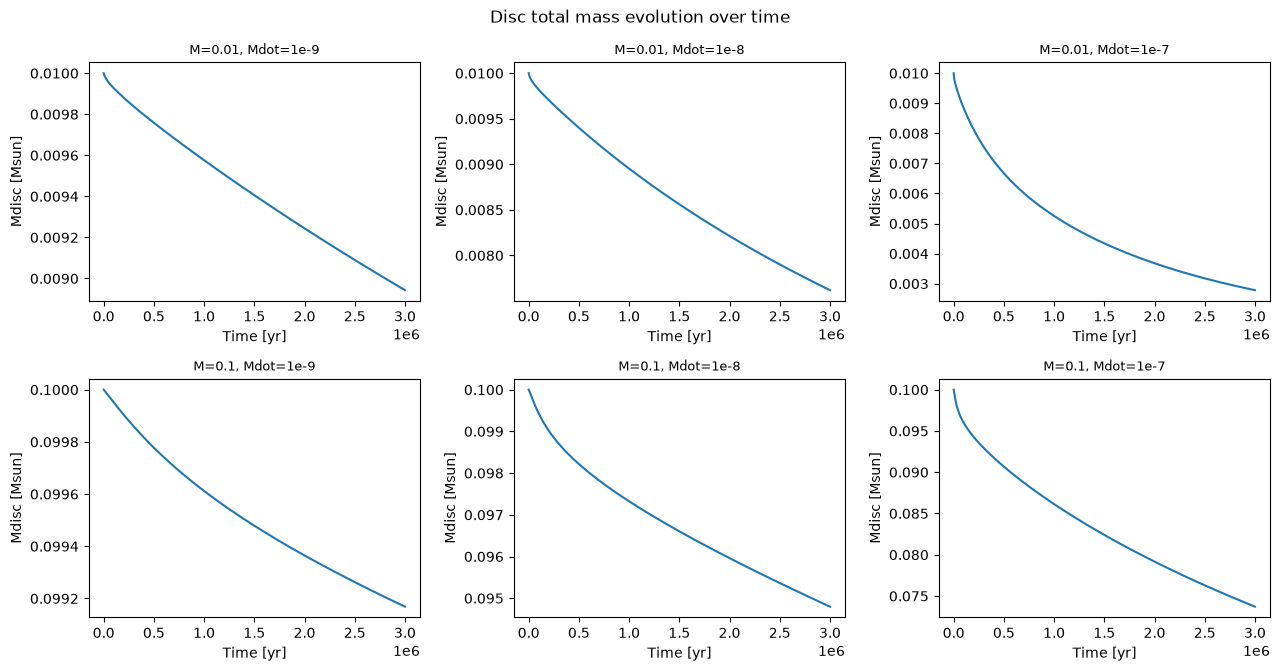

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [yr]', ylabel='Mdisc [Msun]'>]],
       dtype=object))

In [16]:
# Disc total mass evolution over time  (Hof_figures.ipynb cell "Mdisc_t_in_Msun")
def _draw_mdisc(ax, res):
    Mdisc_Msun = np.asarray(res["Mdisc_t"], dtype=float) / Msun   # [g] -> [Msun]
    ax.plot(res["t"], Mdisc_Msun)
    ax.set_ylabel("Mdisc [Msun]")
    ax.set_xlabel("Time [yr]")

plot_grid(_draw_mdisc, suptitle="Disc total mass evolution over time")


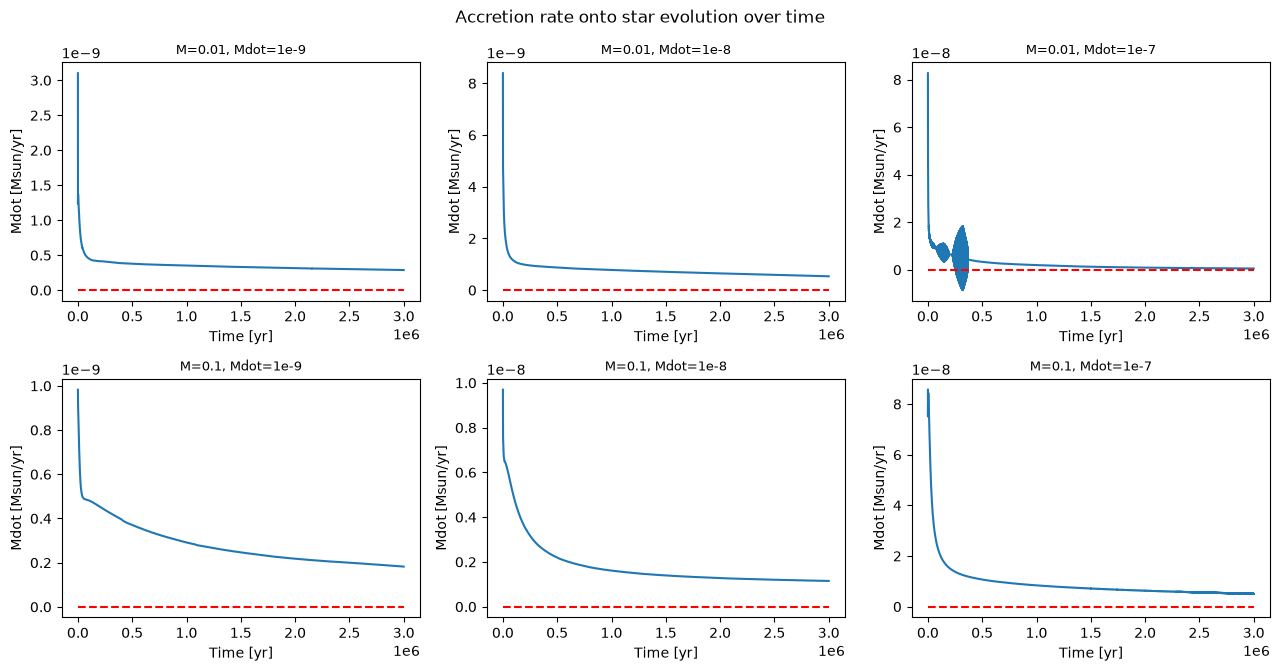

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [yr]', ylabel='Mdot [Msun/yr]'>]],
       dtype=object))

In [17]:
# Accretion rate onto star evolution over time  (Hof_figures.ipynb cell "plt.plot(t, Mdot_t)")
def _draw_mdot(ax, res):
    ax.plot(res["t"], res["Mdot_t"])
    ax.hlines(1e-12, 0.0, 3e6, colors="red", linestyles="dashed")
    ax.set_ylabel("Mdot [Msun/yr]")
    ax.set_xlabel("Time [yr]")

plot_grid(_draw_mdot, suptitle="Accretion rate onto star evolution over time")


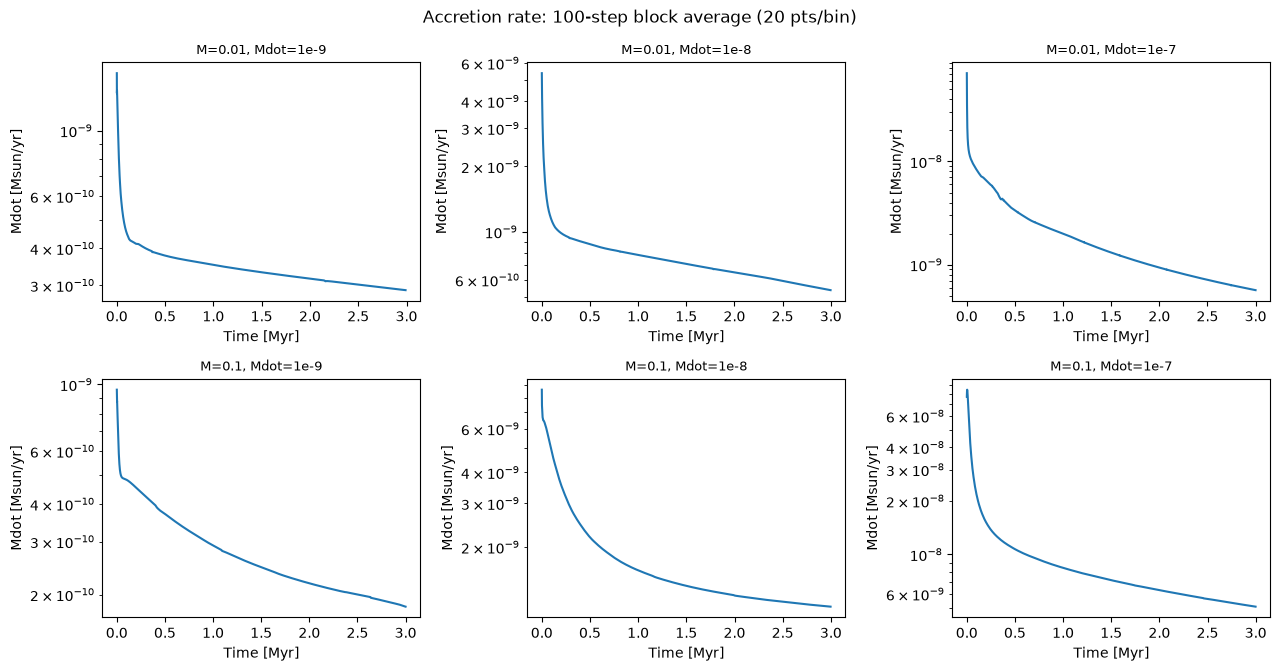

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='Mdot [Msun/yr]'>]],
       dtype=object))

In [18]:
# Accretion rate: N_STEPS_BLOCK_AVG-step block average  (Hof_figures.ipynb cell
# "Plot the average Mdot over every n=100 simulation steps")
#
# disk_Mdot_star (Mdot_t) is written every STEPS_PER_WRITE steps, so
# N_STEPS_BLOCK_AVG steps = N_STEPS_BLOCK_AVG/STEPS_PER_WRITE consecutive
# Mdot_t entries averaged into each output point -- a non-overlapping BLOCK
# average (decimation), not a rolling/moving average.
def _draw_mdot_block_avg(ax, res):
    block = N_STEPS_BLOCK_AVG // STEPS_PER_WRITE
    Mdot_arr = np.asarray(res["Mdot_t"], dtype=float)   # [Msun/yr]
    t_arr = np.asarray(res["t_Myr"], dtype=float)        # [Myr]
    n_blocks = len(Mdot_arr) // block
    Mdot_avg = Mdot_arr[:n_blocks*block].reshape(n_blocks, block).mean(axis=1)
    t_avg = t_arr[:n_blocks*block].reshape(n_blocks, block).mean(axis=1)
    ax.plot(t_avg, Mdot_avg)
    ax.set_yscale("log")
    ax.set_ylabel("Mdot [Msun/yr]")
    ax.set_xlabel("Time [Myr]")

plot_grid(_draw_mdot_block_avg,
          suptitle=f"Accretion rate: {N_STEPS_BLOCK_AVG}-step block average "
                   f"({N_STEPS_BLOCK_AVG // STEPS_PER_WRITE} pts/bin)")


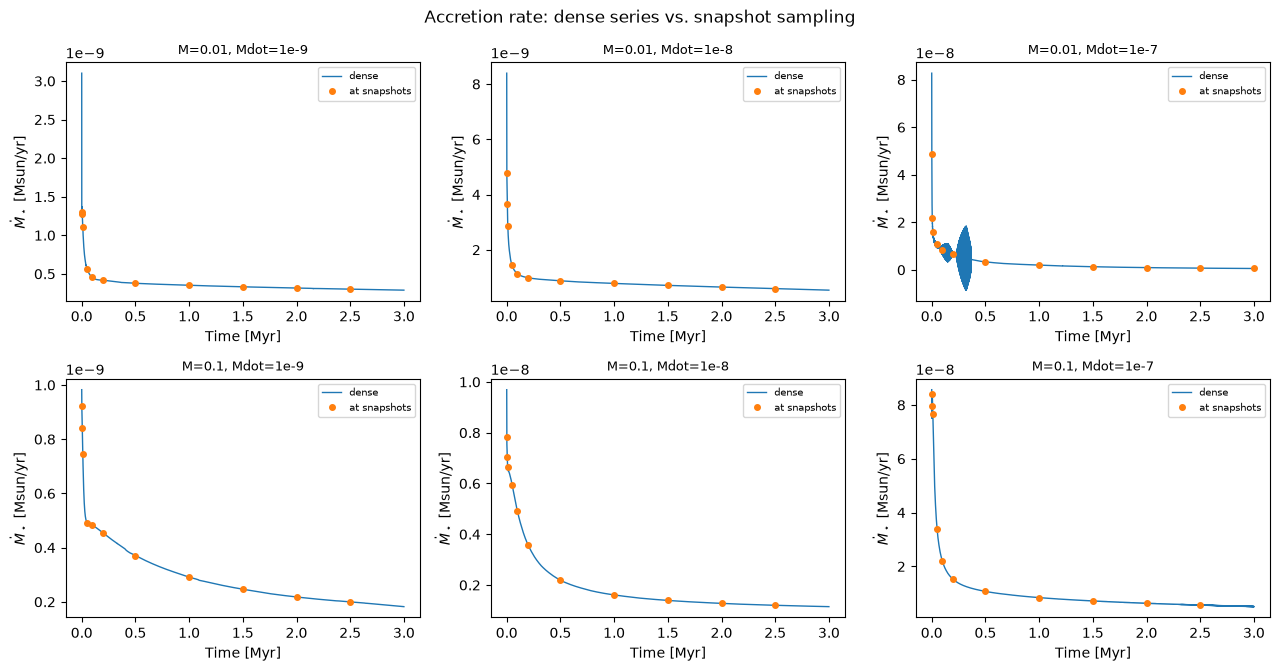

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$\\dot{M}_\\star$ [Msun/yr]'>]],
       dtype=object))

In [19]:
# Accretion rate: dense series vs. snapshot sampling  (Hof_figures.ipynb cell
# "Plot Mdot_t and Mdot_tsnap together")
def _draw_mdot_dense_vs_snap(ax, res):
    ax.plot(res["t_Myr"], res["Mdot_t"], "-", lw=1, label="dense")
    ax.plot(res["t_snap"], res["Mdot_tsnap"], "o", ms=4, label="at snapshots")
    ax.set_ylabel(r"$\dot{M}_\star$ [Msun/yr]")
    ax.set_xlabel("Time [Myr]")
    ax.legend(fontsize=7)

plot_grid(_draw_mdot_dense_vs_snap, suptitle="Accretion rate: dense series vs. snapshot sampling")


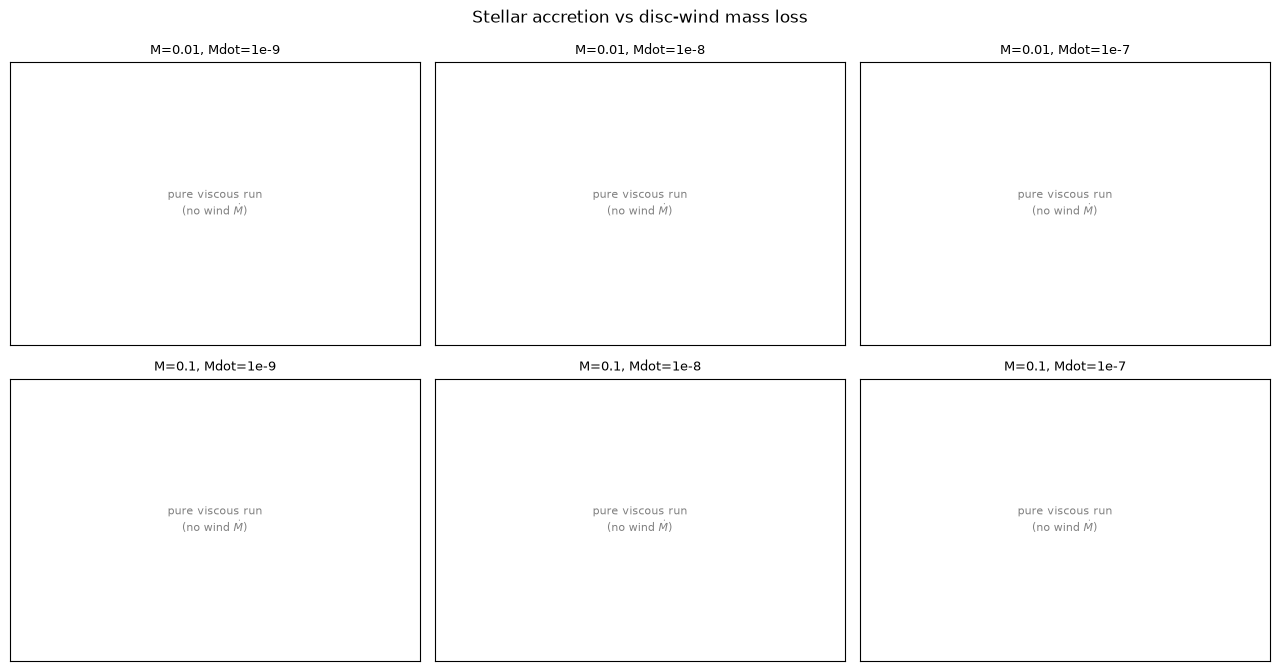

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}>]], dtype=object))

In [20]:
# Stellar accretion vs disc-wind mass loss  (Hof_figures.ipynb cell "Compare
# Mdot_tsnap_mask ... with Mdot_wind_tsnap_mask", left panel)
def _draw_mdot_vs_wind(ax, res):
    if res["is_pure_viscous"]:
        # psi == 0 -- compute_observables() skips integrate_wind_mass_loss_rate()
        # entirely for these runs (it requires psi > 0), so there is no wind
        # Mdot series to plot here. Ported from Hof_figures.ipynb's psi==0 handling.
        ax.text(0.5, 0.5, "pure viscous run\n(no wind $\\dot{M}$)", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        ax.set_xticks([]); ax.set_yticks([])
        return
    ax.plot(res["t_snap_mask"], res["Mdot_tsnap_mask"], "o-", ms=4, label=r"$\dot{M}_\star$")
    ax.plot(res["t_snap_mask"], res["Mdot_wind_tsnap_mask"], "s-", ms=4, label=r"$\dot{M}_{wind}$")
    ax.set_yscale("log")
    ax.set_ylabel(r"$\dot{M}$ [Msun/yr]")
    ax.set_xlabel("Time [Myr]")
    ax.legend(fontsize=7)

plot_grid(_draw_mdot_vs_wind, suptitle="Stellar accretion vs disc-wind mass loss")


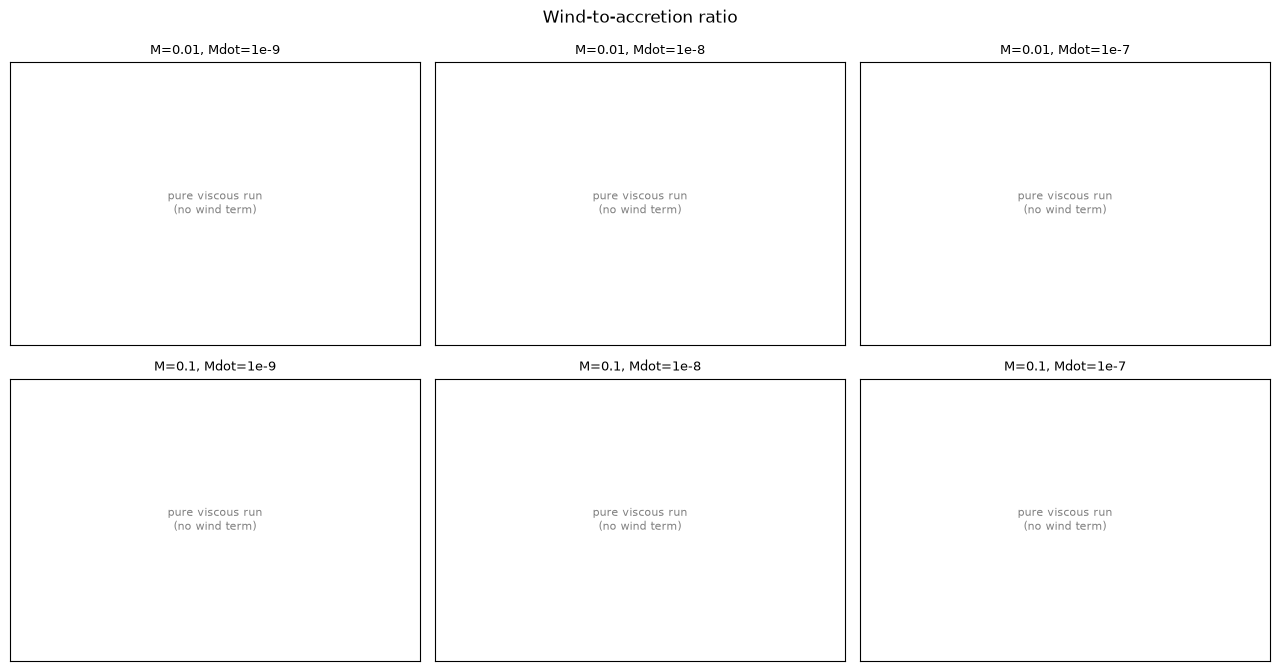

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}>]], dtype=object))

In [21]:
# Wind-to-accretion ratio  (same source cell, right panel)
def _draw_wind_ratio(ax, res):
    if res["is_pure_viscous"]:
        # psi == 0 -- no wind Mdot was computed (see compute_observables()'s
        # is_pure_viscous branch), so the wind/accretion ratio is undefined here.
        ax.text(0.5, 0.5, "pure viscous run\n(no wind term)", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="gray")
        ax.set_xticks([]); ax.set_yticks([])
        return
    ratio = np.asarray(res["Mdot_wind_tsnap_mask"], dtype=float) / np.asarray(res["Mdot_tsnap_mask"], dtype=float)
    ax.plot(res["t_snap_mask"], ratio, "o-", ms=4, color="C2")
    ax.axhline(1.0, color="k", ls="--", lw=1)   # ratio = 1: wind loss balances accretion
    ax.set_ylabel(r"$\dot{M}_{wind}/\dot{M}_\star$")
    ax.set_xlabel("Time [Myr]")

plot_grid(_draw_wind_ratio, suptitle="Wind-to-accretion ratio")


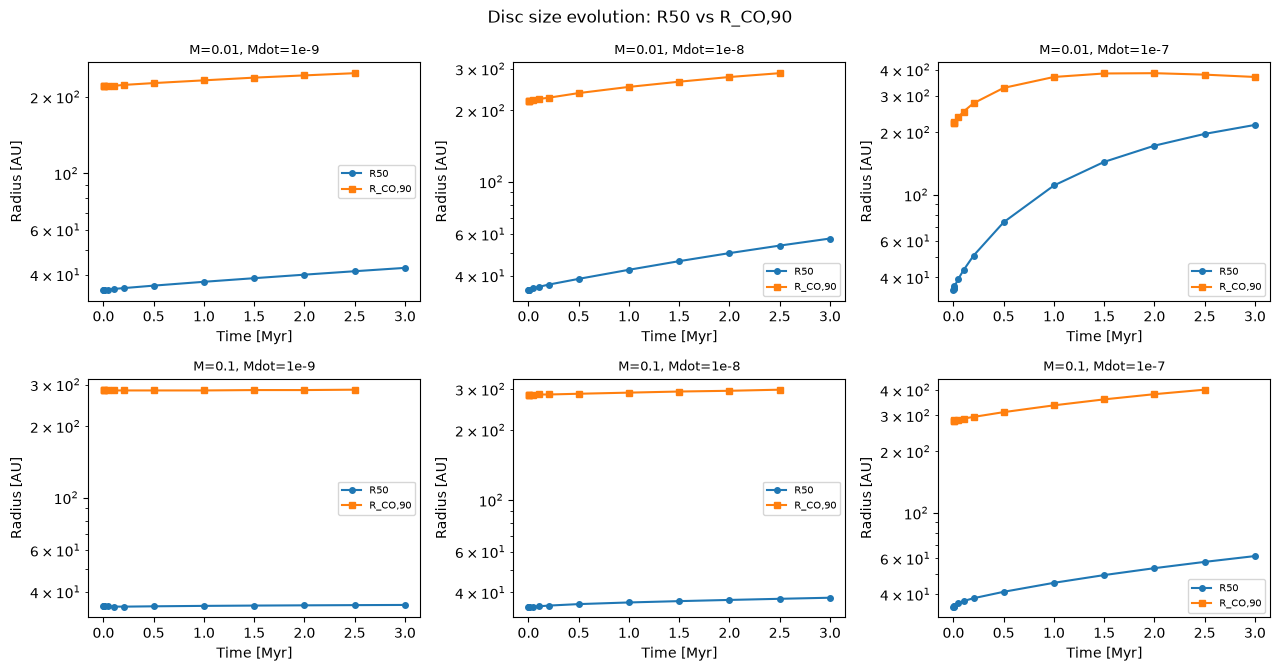

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='Radius [AU]'>]],
       dtype=object))

In [22]:
# Disc size evolution: R50 vs R_CO,90  (Hof_figures.ipynb cell "Compare the
# evolution of R50_tsnap ... and R_CO90_tsnap", left panel)
def _draw_radii(ax, res):
    ax.plot(res["t_snap"], res["R50_tsnap"], "o-", ms=4, label="R50")
    ax.plot(res["t_snap"], res["R_CO90_tsnap"], "s-", ms=4, label="R_CO,90")
    ax.set_yscale("log")
    ax.set_ylabel("Radius [AU]")
    ax.set_xlabel("Time [Myr]")
    ax.legend(fontsize=7)

plot_grid(_draw_radii, suptitle="Disc size evolution: R50 vs R_CO,90")


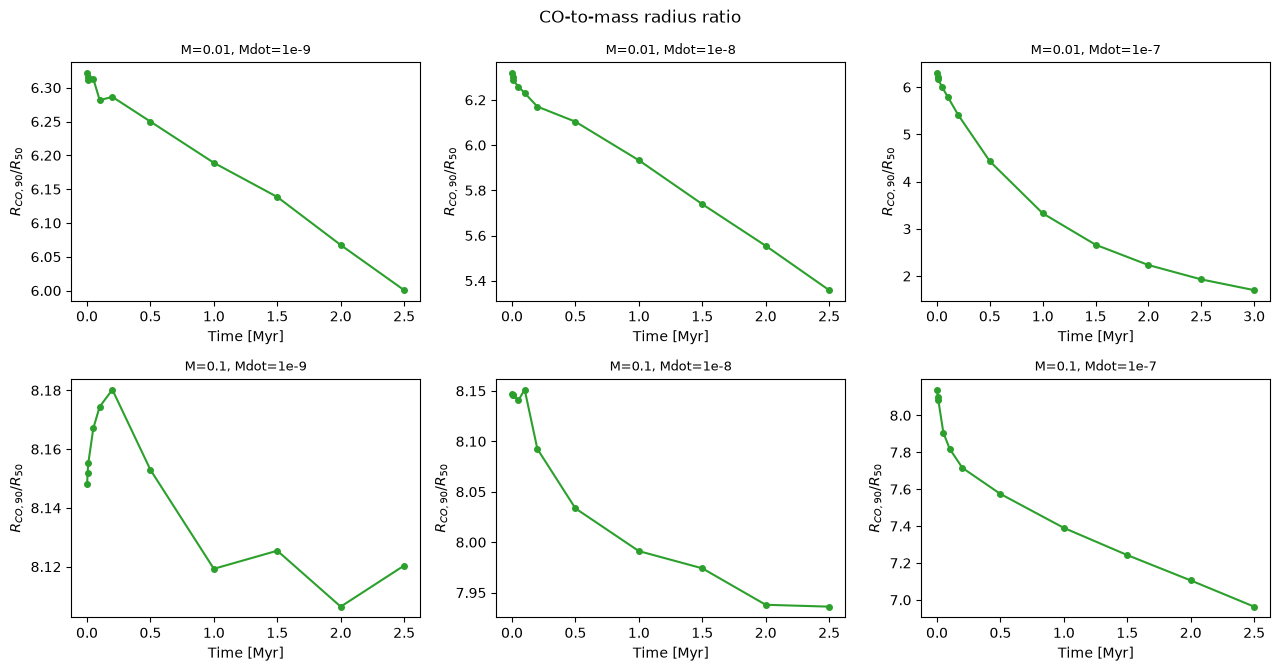

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$R_{CO,90}/R_{50}$'>]],
       dtype=object))

In [23]:
# CO-to-mass radius ratio  (same source cell, right panel)
def _draw_radii_ratio(ax, res):
    ratio = np.asarray(res["R_CO90_tsnap"], dtype=float) / np.asarray(res["R50_tsnap"], dtype=float)
    ax.plot(res["t_snap"], ratio, "o-", ms=4, color="C2")
    ax.set_ylabel(r"$R_{CO,90}/R_{50}$")
    ax.set_xlabel("Time [Myr]")

plot_grid(_draw_radii_ratio, suptitle="CO-to-mass radius ratio")


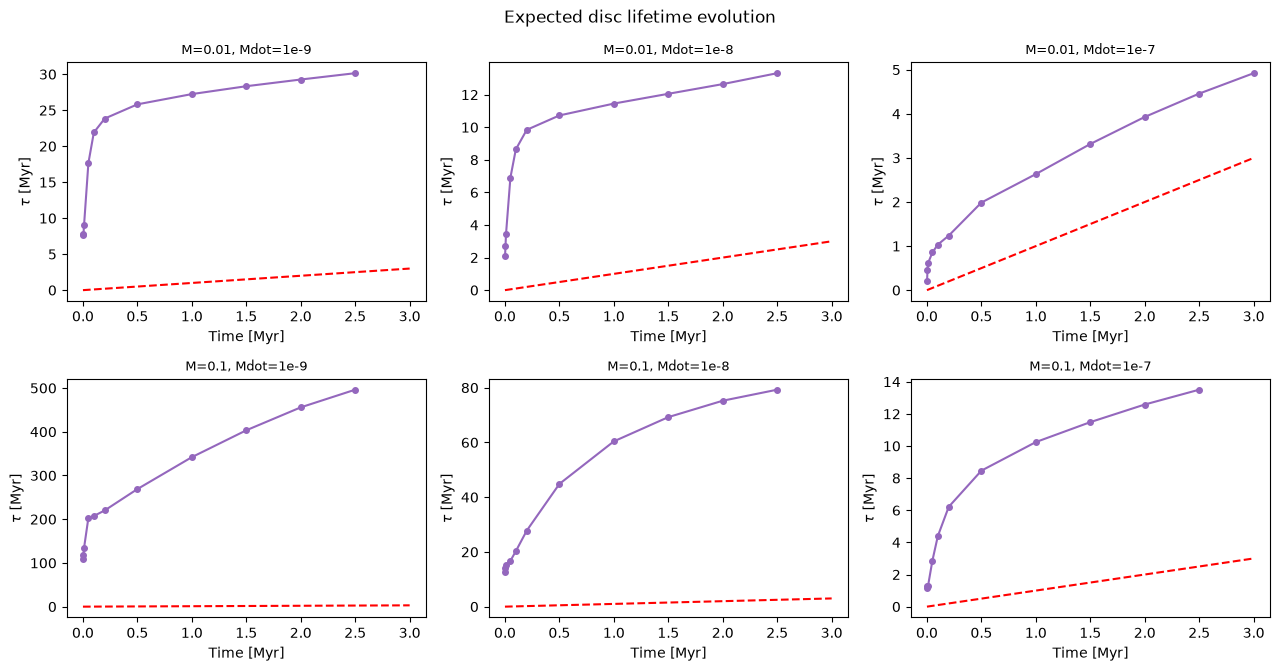

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='Time [Myr]', ylabel='$\\tau$ [Myr]'>]],
       dtype=object))

In [24]:
# Expected disc lifetime evolution  (Hof_figures.ipynb cell "Plot that shows
# time evolution of expected disc lifetime tau"). The red dashed y=x line
# marks where tau equals the elapsed time itself.
#
# x-axis is res["tau_t_snap"] -- t_snap_mask for a normal (psi != 0) run, or
# the FULL t_snap grid for a pure-viscous (psi == 0) run (see
# compute_observables()'s is_pure_viscous branch, ported from
# Hof_figures.ipynb's psi==0 handling in its "tau" cell); tau/tau_Myr are
# already paired 1:1 with tau_t_snap in both cases, so no branching is needed here.
def _draw_tau(ax, res):
    ax.plot(res["tau_t_snap"], res["tau_Myr"], "o-", ms=4, color="C4")
    ax.plot(res["tau_t_snap"], res["tau_t_snap"], "--", color="red")
    ax.set_ylabel(r"$\tau$ [Myr]")
    ax.set_xlabel("Time [Myr]")

plot_grid(_draw_tau, suptitle="Expected disc lifetime evolution")


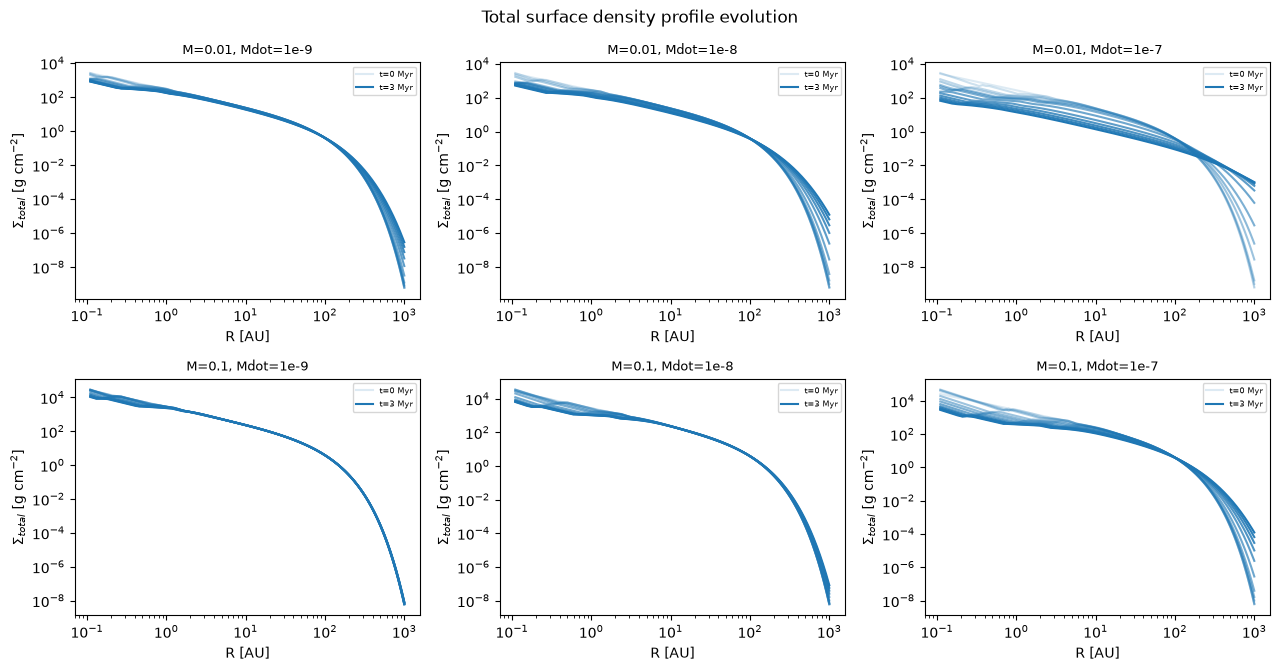

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='R [AU]', ylabel='$\\Sigma_{total}$ [g cm$^{-2}$]'>]],
       dtype=object))

In [25]:
# Total surface density profile evolution  (Hof_figures.ipynb "Balogh et al.
# 2026"-style cell, Figure 1). Same color per panel, opacity ramps from faint
# (earliest snapshot) to opaque (latest); legend only labels the first/last
# snapshot to avoid clutter.
def _draw_sigma_profile(ax, res):
    R_au = np.asarray(res["data"]["R"], dtype=float)
    Sigma_total_tsnap = res["Sigma_total_tsnap"]
    t_snap = res["t_snap"]
    n_snap = len(t_snap)
    alphas = np.linspace(0.15, 1.0, n_snap)
    for i in range(n_snap):
        label = f"t={t_snap[i]:.3g} Myr" if i in (0, n_snap - 1) else None
        ax.plot(R_au, Sigma_total_tsnap[i], color="C0", alpha=alphas[i], label=label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel(r"$\Sigma_{total}$ [g cm$^{-2}$]")
    ax.set_xlabel("R [AU]")
    ax.legend(fontsize=6)

plot_grid(_draw_sigma_profile, suptitle="Total surface density profile evolution")


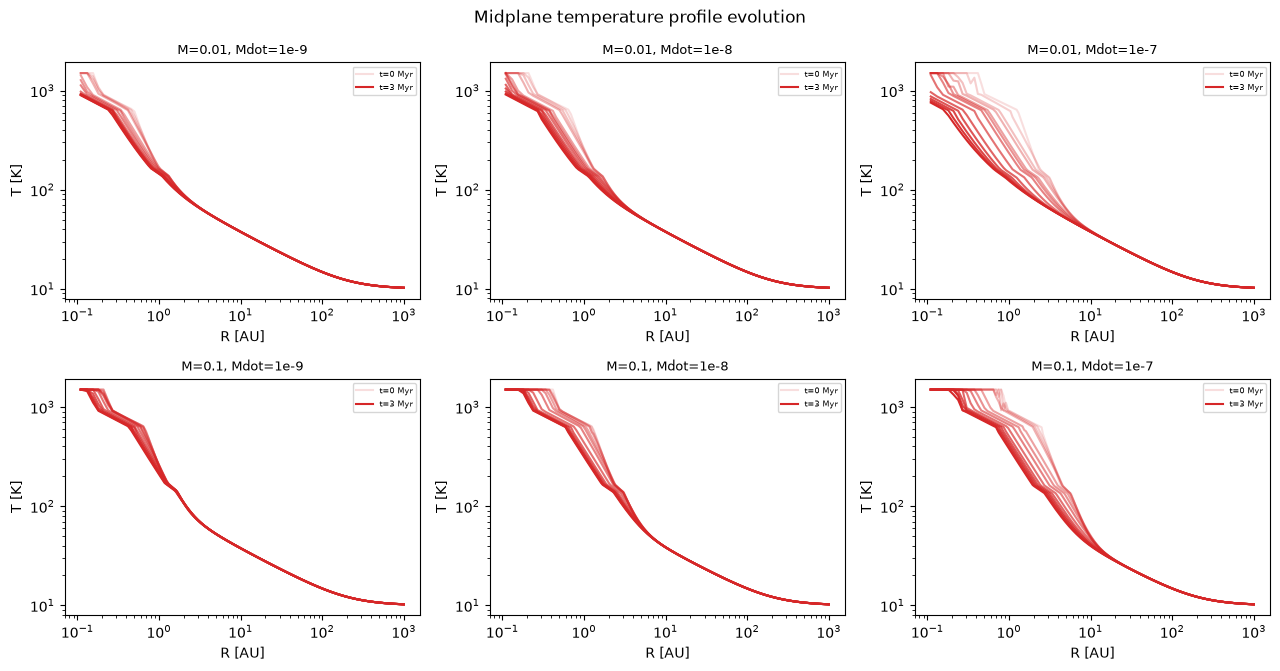

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}, xlabel='R [AU]', ylabel='T [K]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}, xlabel='R [AU]', ylabel='T [K]'>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}, xlabel='R [AU]', ylabel='T [K]'>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}, xlabel='R [AU]', ylabel='T [K]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}, xlabel='R [AU]', ylabel='T [K]'>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}, xlabel='R [AU]', ylabel='T [K]'>]],
       dtype=object))

In [26]:
# Midplane temperature profile evolution  (same source cell, Figure 2)
def _draw_T_profile(ax, res):
    R_au = np.asarray(res["data"]["R"], dtype=float)
    Temp_tsnap = np.asarray(res["data"]["T"], dtype=float)
    t_snap = res["t_snap"]
    n_snap = len(t_snap)
    alphas = np.linspace(0.15, 1.0, n_snap)
    for i in range(n_snap):
        label = f"t={t_snap[i]:.3g} Myr" if i in (0, n_snap - 1) else None
        ax.plot(R_au, Temp_tsnap[i], color="C3", alpha=alphas[i], label=label)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("T [K]")
    ax.set_xlabel("R [AU]")
    ax.legend(fontsize=6)

plot_grid(_draw_T_profile, suptitle="Midplane temperature profile evolution")


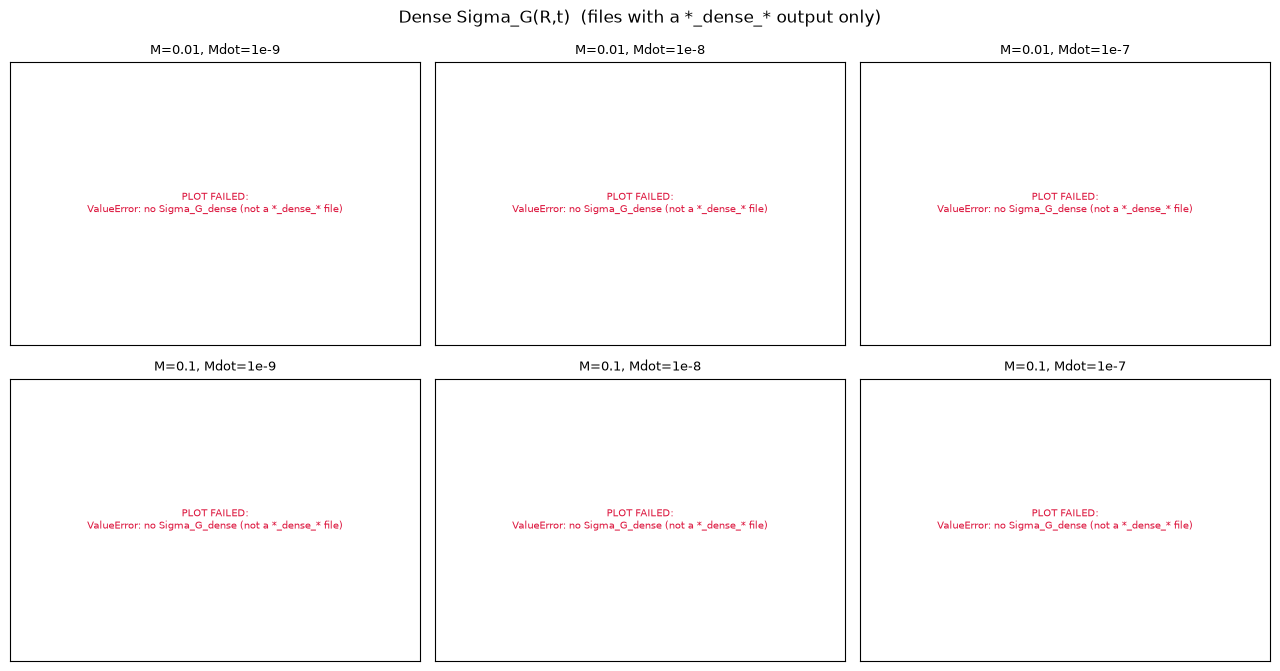

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}>]], dtype=object))

In [27]:
# Dense Sigma_G(R,t) heatmap, full radial range  (Hof_figures.ipynb cell "Add
# plot for dense array of Sigma_G"). Only files with a Sigma_G_dense dataset
# (run_model_Hof_dense.py output, filename contains "_dense_") have this --
# every other file gets a "PLOT FAILED: no Sigma_G_dense" panel via
# plot_grid()'s per-panel error handling, rather than breaking the grid.
def _draw_dense_heatmap(ax, res):
    if "Sigma_G_dense" not in res["data"]:
        raise ValueError("no Sigma_G_dense (not a *_dense_* file)")
    R_au = np.asarray(res["data"]["R"], dtype=float)
    t_dense_Myr = np.asarray(res["data"]["Sigma_G_dense_t"], dtype=float) / 1e6
    Sigma_G_dense = np.asarray(res["data"]["Sigma_G_dense"], dtype=float)
    positive = Sigma_G_dense[Sigma_G_dense > 0]   # LogNorm needs strictly-positive bounds
    pcm = ax.pcolormesh(R_au, t_dense_Myr, Sigma_G_dense,
                         norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
                         shading="auto", cmap="viridis")
    ax.set_xscale("log")
    ax.set_ylabel("Time [Myr]")
    ax.set_xlabel("R [AU]")
    plt.colorbar(pcm, ax=ax, label=r"$\Sigma_G$ [g cm$^{-2}$]")

plot_grid(_draw_dense_heatmap, suptitle="Dense Sigma_G(R,t)  (files with a *_dense_* output only)")


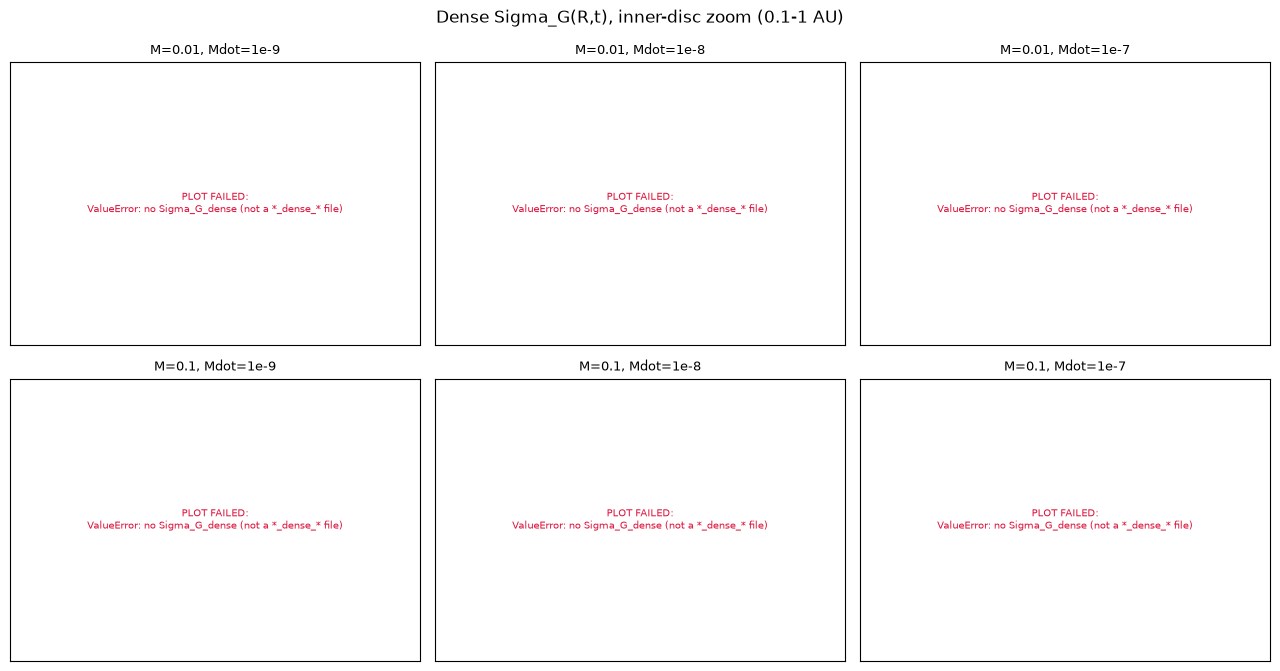

(<Figure size 1290x680 with 6 Axes>,
 array([[<Axes: title={'center': 'M=0.01, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.01, Mdot=1e-7'}>],
        [<Axes: title={'center': 'M=0.1, Mdot=1e-9'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-8'}>,
         <Axes: title={'center': 'M=0.1, Mdot=1e-7'}>]], dtype=object))

In [28]:
# Dense Sigma_G(R,t) heatmap, zoomed to the inner disc  (Hof_figures.ipynb's
# most recent edit to the cell above) -- same data, restricted to
# R_ZOOM_MIN < R <= R_ZOOM_MAX (set in "Analysis parameters" above) so
# fluctuations near the inner boundary are visible instead of swamped by the
# full 0.1-1000 AU dynamic range.
def _draw_dense_heatmap_zoom(ax, res):
    if "Sigma_G_dense" not in res["data"]:
        raise ValueError("no Sigma_G_dense (not a *_dense_* file)")
    R_au_full = np.asarray(res["data"]["R"], dtype=float)
    t_dense_Myr = np.asarray(res["data"]["Sigma_G_dense_t"], dtype=float) / 1e6
    Sigma_full = np.asarray(res["data"]["Sigma_G_dense"], dtype=float)

    in_zoom = (R_au_full > R_ZOOM_MIN) & (R_au_full <= R_ZOOM_MAX)
    R_au = R_au_full[in_zoom]
    Sigma_G_dense = Sigma_full[:, in_zoom]

    positive = Sigma_G_dense[Sigma_G_dense > 0]
    pcm = ax.pcolormesh(R_au, t_dense_Myr, Sigma_G_dense,
                         norm=LogNorm(vmin=positive.min(), vmax=positive.max()),
                         shading="auto", cmap="viridis")
    ax.set_xscale("log")
    ax.set_ylabel("Time [Myr]")
    ax.set_xlabel("R [AU]")
    plt.colorbar(pcm, ax=ax, label=r"$\Sigma_G$ [g cm$^{-2}$]")

plot_grid(_draw_dense_heatmap_zoom,
          suptitle=f"Dense Sigma_G(R,t), inner-disc zoom ({R_ZOOM_MIN:.3g}-{R_ZOOM_MAX:.3g} AU)")
